### Downloading Data & visualizing it 

In [16]:
import kagglehub

path = kagglehub.dataset_download('andrewmvd/pollen-grain-image-classification')
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pollen-grain-image-classification' dataset.
Path to dataset files: /kaggle/input/pollen-grain-image-classification


Found 790 images.
Displaying image: /kaggle/input/pollen-grain-image-classification/combretum_11.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/faramea_15.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/myrcia_34.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/croton_22.jpg
Displaying image: /kaggle/input/pollen-grain-image-classification/arecaceae_16.jpg


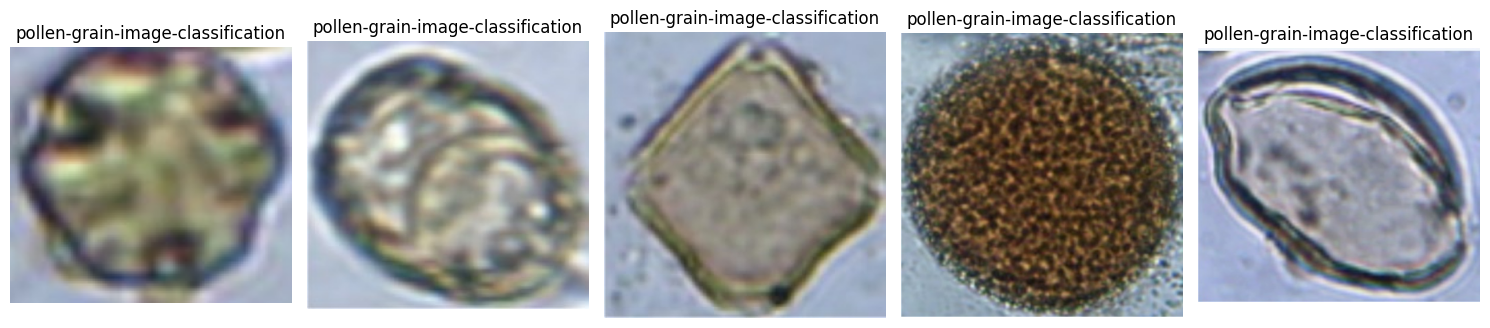

In [17]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Walk through the directory to find image files
image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} images.")

# Display the first 5 images
num_images_to_show = 5

if num_images_to_show > 0:
    plt.figure(figsize=(15, 5))
    for i in range(num_images_to_show):
        img_path = image_files[i]
        print(f"Displaying image: {img_path}")
        img = Image.open(img_path)
        
        # Plot each image
        plt.subplot(1, num_images_to_show, i + 1)
        plt.imshow(img)
        
        # Use the parent folder name as the title (usually the class label)
        label = os.path.basename(img_path.split(os.sep)[-2])
        plt.title(label)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("No images found in the downloaded dataset.")

### Organizing data inside workdir 

In [18]:
import os
import shutil
from PIL import Image as PILImage

# 1. Define where we want to put the organized folders
organized_path = "./data/organized_pollen_data"

# Clear existing organized data to avoid stale/corrupt files from previous runs
if os.path.exists(organized_path):
    shutil.rmtree(organized_path)
os.makedirs(organized_path, exist_ok=True)

print("Starting to organize files...")

skipped = 0
copied = 0

for img_path in image_files:
    # Validate the file is a real, decodable image before copying
    try:
        with PILImage.open(img_path) as img:
            img.verify()  # raises if the file is corrupt or not a real image
        if PILImage.open(img_path).format not in ('JPEG', 'PNG', 'GIF', 'BMP', 'WEBP'):
            print(f"Skipping unsupported format: {img_path}")
            skipped += 1
            continue
    except Exception as e:
        print(f"Skipping corrupt/invalid file: {img_path} ({e})")
        skipped += 1
        continue

    filename = os.path.basename(img_path)

    # 2. Extract the class name from the filename
    parts = filename.split('_')
    class_name = "_".join(parts[:-1])

    # 3. Create a folder for this class if it doesn't exist yet
    class_folder = os.path.join(organized_path, class_name)
    os.makedirs(class_folder, exist_ok=True)

    # 4. Copy the image into its class folder
    dest_path = os.path.join(class_folder, filename)
    shutil.copy(img_path, dest_path)
    copied += 1

print(f"\nDone! Copied {copied} valid images, skipped {skipped} invalid files.")
print(f"Data organized into: {organized_path}")

Starting to organize files...
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/myrcia_22.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/myrcia_28.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/myrcia_31.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/cecropia_12.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/syagrus_18.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/myrcia_15.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/urochloa (13).jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/cecropia_10.jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/urochloa (12).jpg
Skipping unsupported format: /kaggle/input/pollen-grain-image-classification/cecropia_05.jpg
Skipping unsupported format: /kaggle/input/po

In [19]:
import tensorflow as tf

# 1. Define standard variables
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224) 

print("Loading data...")

# 2. Create the Training Dataset (80% of the images)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,                    # The directory you got from Kagglehub
    validation_split=0.2,    # Keep 20% of data aside for testing
    subset="training",       # This defines that we are making the training set
    seed=123,                # A random seed ensures we get the same split every time
    image_size=IMAGE_SIZE,   # Resizes all images to 224x224 pixels
    batch_size=BATCH_SIZE    # Groups images into batches of 32
)

# 3. Create the Validation Dataset (20% of the images)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    organized_path,
    validation_split=0.2,
    subset="validation",     # This defines that we are making the testing set
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 4. Extract and print the class names
class_names = train_dataset.class_names
print(f"Found {len(class_names)} different types of pollen:")
print(class_names)

Loading data...
Found 655 files belonging to 21 classes.
Using 524 files for training.
Found 655 files belonging to 21 classes.
Using 131 files for validation.
Found 21 different types of pollen:
['anadenanthera', 'arecaceae', 'arrabidaea', 'cecropia', 'chromolaena', 'combretum', 'croton', 'dipteryx', 'eucalipto', 'faramea', 'hyptis', 'mabea', 'matayba', 'mimosa', 'myrcia', 'protium', 'qualea', 'schinus', 'serjania', 'syagrus', 'tridax']


In [20]:
# Block 4: Building the CNN Model
num_classes = len(class_names)

print("Building the CNN Brain...")

model = tf.keras.Sequential([
    # Pre-processing: Make pixel values between 0 and 1
    tf.keras.layers.Rescaling(1./255, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    
    # 1st Convolutional Block (Looks for simple edges)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # 2nd Convolutional Block (Looks for complex pollen textures)
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # Transition to Decision Making
    tf.keras.layers.Flatten(),
    
    # Decision Making Network
    tf.keras.layers.Dense(128, activation='relu'),
    
    # Final Output Layer (Must match the number of classes)
    # 'softmax' turns the output into percentages (e.g., 90% sure it's Oak, 10% Pine)
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Print a map of the network
model.summary()

Building the CNN Brain...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,910,101 (91.21 MB)

 Trainable params: 23,910,101 (91.21 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Block 5: Compiling and Training

print("Setting the learning rules...")
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # Math formula to calculate how wrong the AI is
    metrics=['accuracy']                    # We want to track the percentage of correct guesses
)

print("Starting training! Grab a coffee, this might take a few minutes...")

# 'history' will save the grades of the AI so we can graph them later
epochs_to_train = 10 

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs_to_train
)

print("Training Complete!")

Setting the learning rules...
Starting training! Grab a coffee, this might take a few minutes...
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.0477 - loss: 5.7025 - val_accuracy: 0.0687 - val_loss: 2.9480
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.1412 - loss: 2.7199 - val_accuracy: 0.1832 - val_loss: 2.4947
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.3130 - loss: 2.1000 - val_accuracy: 0.3588 - val_loss: 2.1653
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.5000 - loss: 1.6662 - val_accuracy: 0.5496 - val_loss: 1.5520
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.6832 - loss: 1.1492 - val_accuracy: 0.5573 - val_loss: 1.2914
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.7844 - loss: 0.8062 - val_accuracy: 0.6336 - val_loss: 1.1396
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8378 - loss: 0.6104 - val_accuracy: 0.6489 - val_loss: 1.1041
Epoch 8/10
17/17 ━━━━

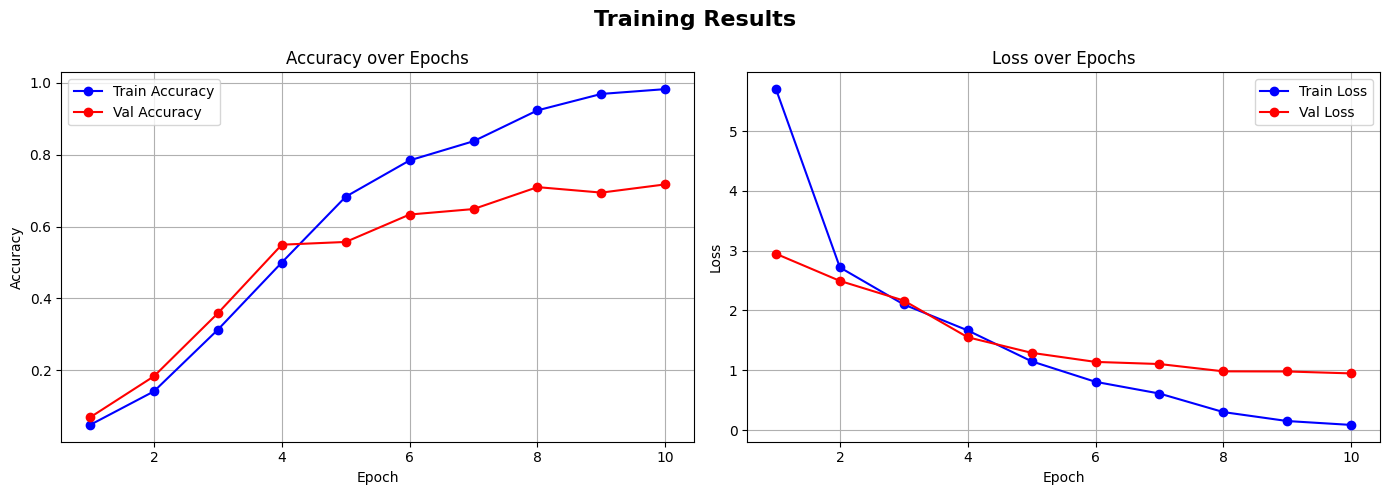

In [22]:
import matplotlib.pyplot as plt
import numpy as np

acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Results', fontsize=16, fontweight='bold')

# --- Accuracy ---
axes[0].plot(epochs, acc,     'b-o', label='Train Accuracy')
axes[0].plot(epochs, val_acc, 'r-o', label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss ---
axes[1].plot(epochs, loss,     'b-o', label='Train Loss')
axes[1].plot(epochs, val_loss, 'r-o', label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Predict on 5 Sample Images

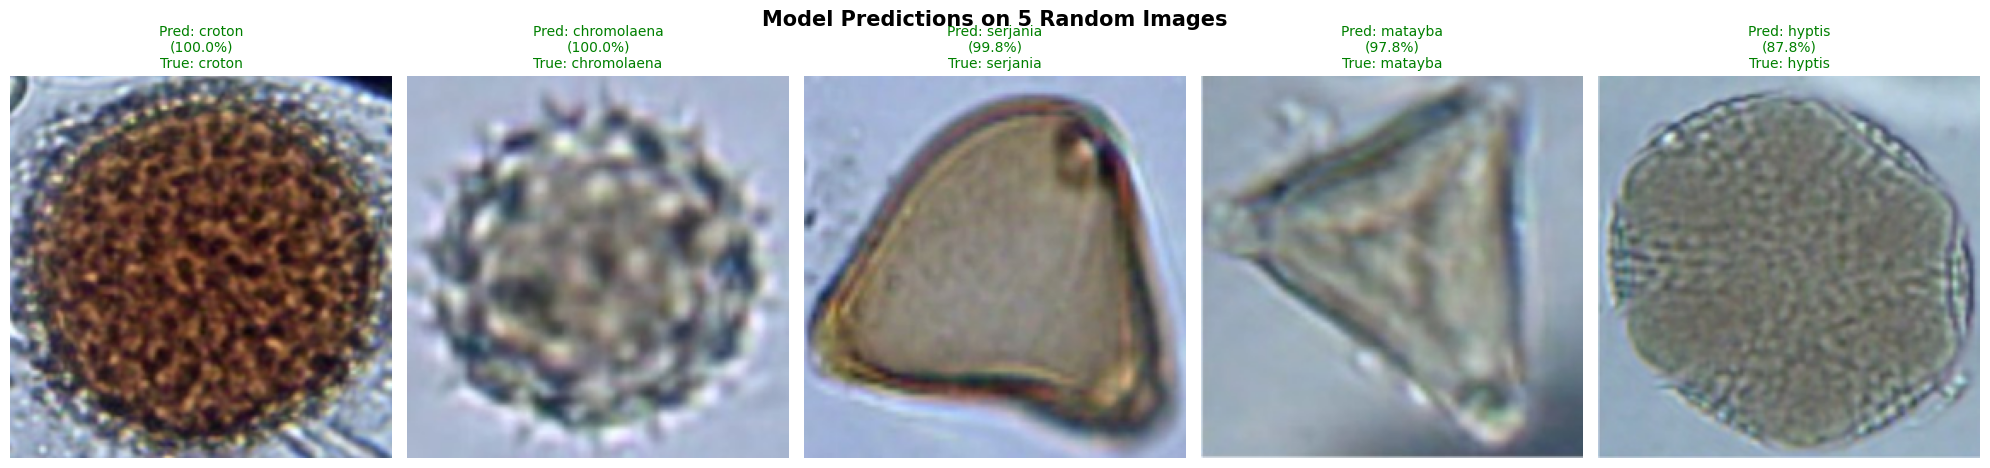

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image as PILImage
import random, os

# ── Pick 5 random images from the organized folder ──────────────────────────
all_image_paths = []
all_image_labels = []
for class_name in os.listdir(organized_path):
    class_dir = os.path.join(organized_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        all_image_paths.append(os.path.join(class_dir, fname))
        all_image_labels.append(class_name)

sample_indices = random.sample(range(len(all_image_paths)), 5)
sample_paths   = [all_image_paths[i] for i in sample_indices]
sample_labels  = [all_image_labels[i] for i in sample_indices]

# ── Run model predictions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Model Predictions on 5 Random Images', fontsize=15, fontweight='bold')

for ax, img_path, true_label in zip(axes, sample_paths, sample_labels):
    # Load and preprocess
    img = PILImage.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)  # shape (1,224,224,3)

    # Predict
    predictions  = model.predict(img_array, verbose=0)[0]
    predicted_idx   = np.argmax(predictions)
    predicted_class = class_names[predicted_idx]
    confidence      = predictions[predicted_idx] * 100

    # Color the title green if correct, red if wrong
    color = 'green' if predicted_class == true_label else 'red'

    ax.imshow(img)
    ax.set_title(
        f"Pred: {predicted_class}\n({confidence:.1f}%)\nTrue: {true_label}",
        color=color, fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()